Processing: SAMTEX.bot407.2005
RMS: 1.23
❌ Missing: SAMTEX.mof107.2005
❌ Missing: SAMTEX.kim432.2004
❌ Missing: SAMTEX.san008.2008
❌ Missing: SAMTEX.san006.2008
❌ Missing: SAMTEX.bot228.2005
❌ Missing: SAMTEX.rtz401.2005
❌ Missing: SAMTEX.san011.2008
❌ Missing: SAMTEX.kim422.2004
❌ Missing: SAMTEX.rtz417.2005
Processing: SAMTEX.kal017.2008
RMS: 2.27
❌ Missing: SAMTEX.kim435.2004
Processing: SAMTEX.k2g006.2006
RMS: 1.92
❌ Missing: SAMTEX.mak002.2006
Processing: SAMTEX.ELZ291A.2008
RMS: 4.24
❌ Missing: SAMTEX.zim128.2005
Processing: SAMTEX.kap010.2003
RMS: 2.96
❌ Missing: SAMTEX.mof102.2005
❌ Missing: SAMTEX.oka008.2006
Processing: SAMTEX.CPV027.2006
RMS: nan
Processing: SAMTEX.dmb017.2006
RMS: 2.83
Processing: SAMTEX.kap067.2003
RMS: nan
Processing: SAMTEX.bot416.2005
RMS: 1.60
❌ Missing: SAMTEX.NEN003.2006


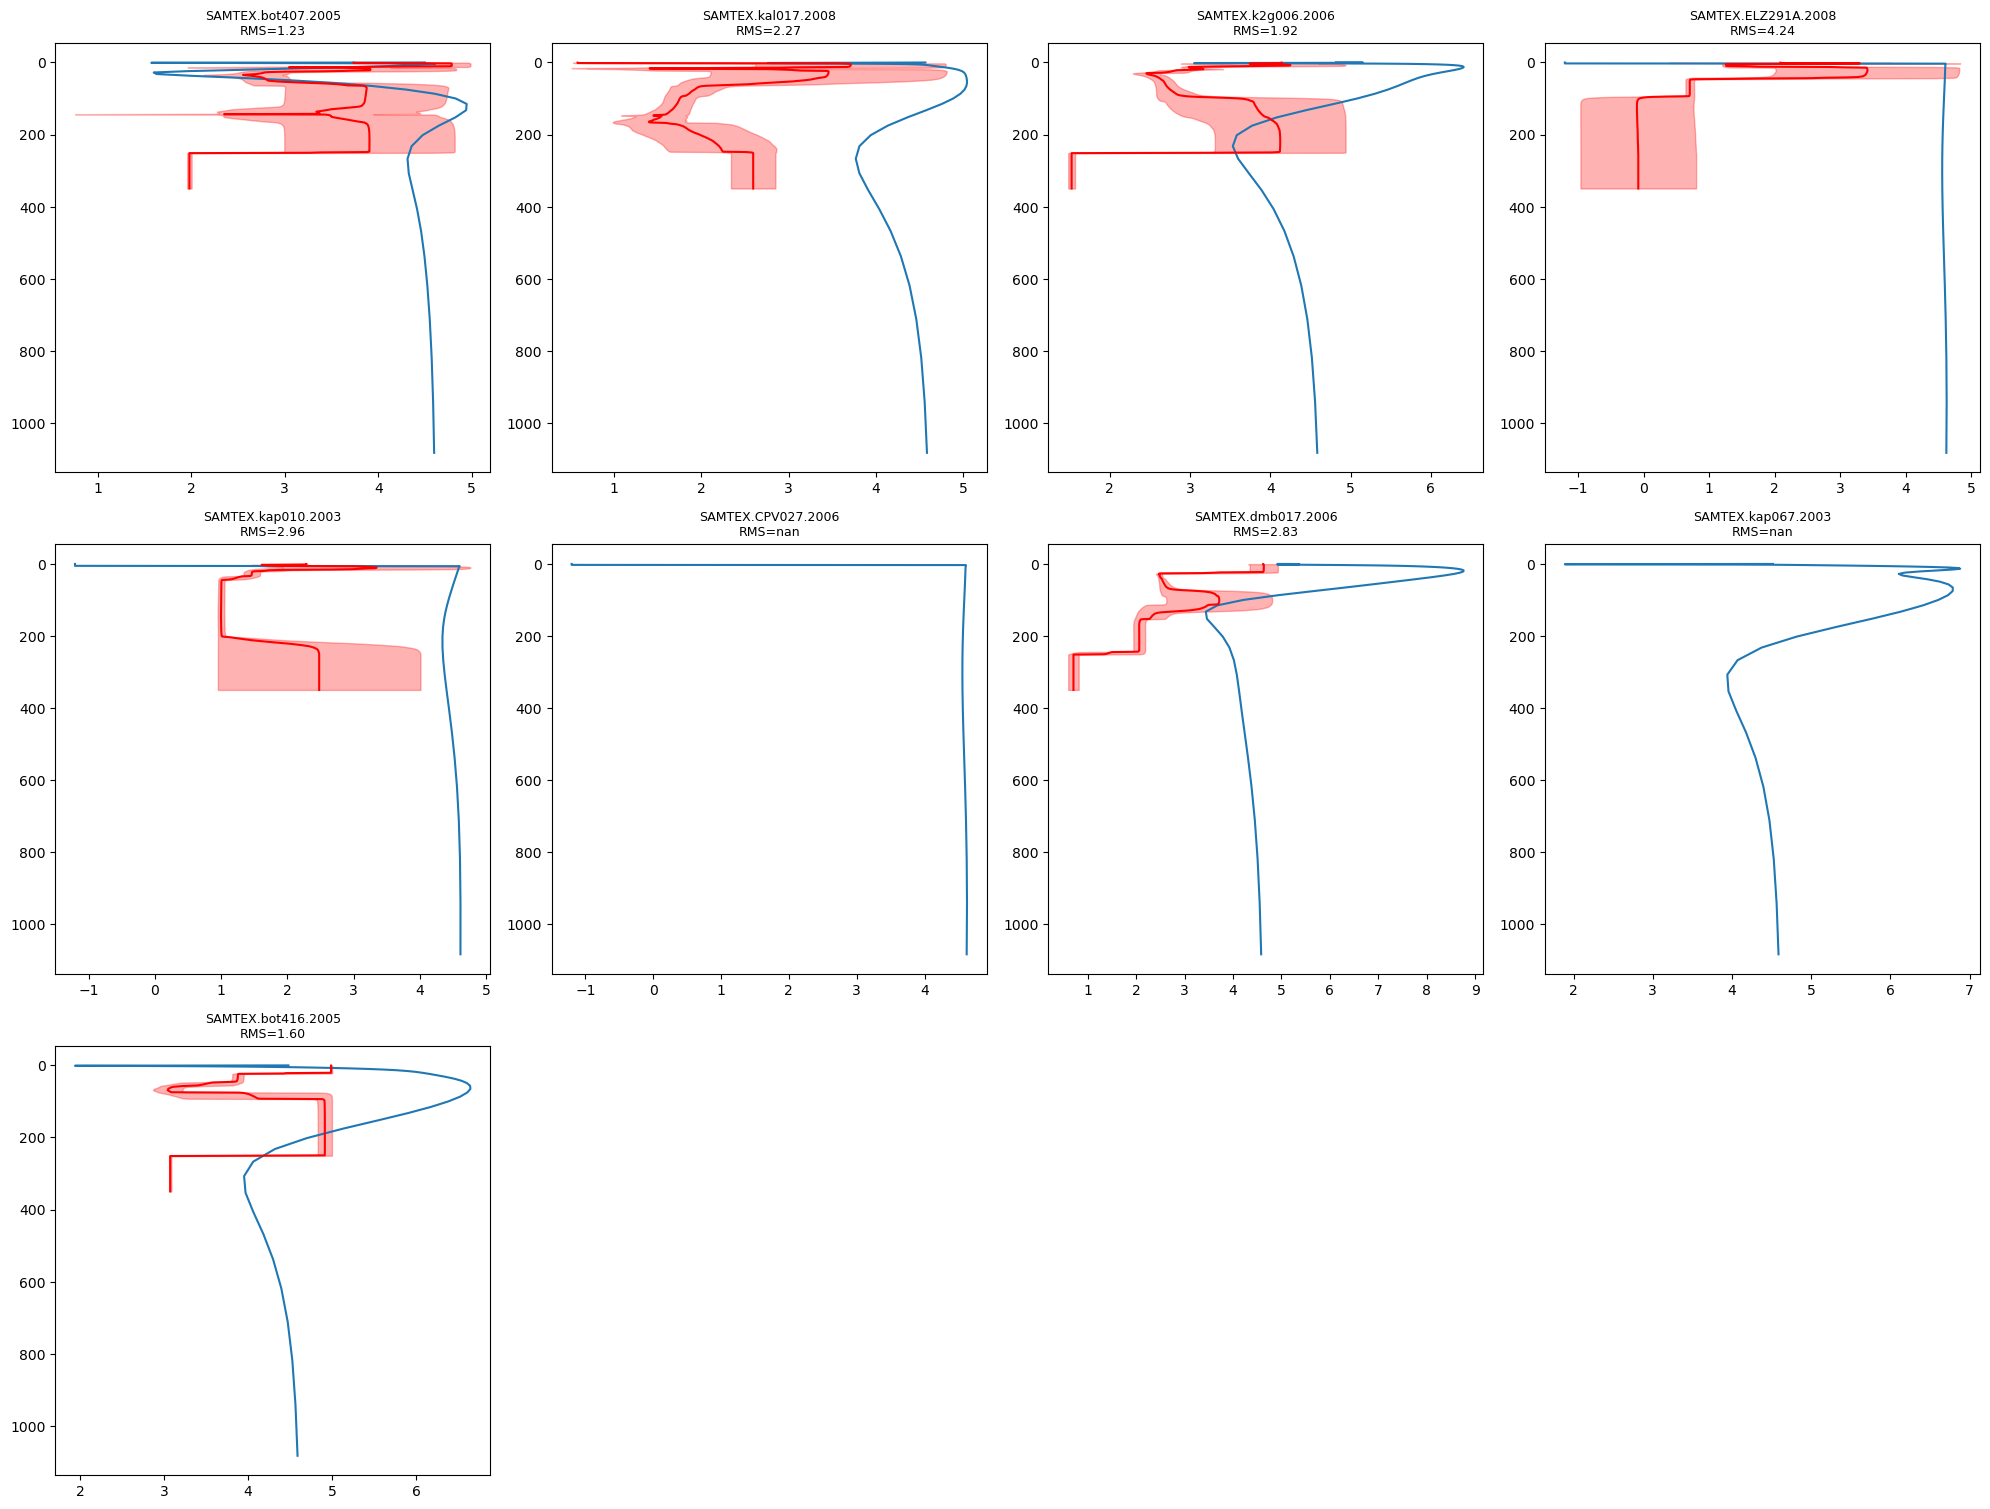

✅ Done: All stations processed


In [3]:
# =========================
# COMPLETE RUN SCRIPT
# =========================

import os
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# =========================
# FUNCTION: Read ModEM rho
# =========================
def read_modem_rho(filepath):
    with open(filepath, 'r') as f:
        lines = [l.strip() for l in f if l.strip()]

    lines = [l for l in lines if not l.startswith('#')]

    header_tokens = lines[0].replace(",", " ").split()
    header_nums = []
    for tok in header_tokens:
        try:
            header_nums.append(int(float(tok)))
        except ValueError:
            continue

    if len(header_nums) < 3:
        raise ValueError(f"Could not parse grid dimensions (nx, ny, nz) from header line: {lines[0]}")

    nx, ny, nz = header_nums[:3]

    dx = np.array(list(map(float, lines[1].split())))
    dy = np.array(list(map(float, lines[2].split())))
    dz = np.array(list(map(float, lines[3].split())))

    total = nx * ny * nz

    values = []
    for line in lines[4:]:
        for val in line.split():
            try:
                values.append(float(val))
                if len(values) == total:
                    break
            except:
                continue
        if len(values) == total:
            break

    log_rho = np.array(values).reshape((nx, ny, nz), order='F')
    rho = 10 ** log_rho
    depth = np.cumsum(dz)

    return rho, depth, dx, dy


# =========================
# LOAD DATA (ONCE)
# =========================
df = pd.read_csv("output/csv/all_csv_files/selected_24_stations.csv")

# =========================
# LOAD MODEL FIRST
# =========================
rho, depth, dx, dy = read_modem_rho("../SA2022ModelsAndData/ModEM_Selected/ModEM_SA2022_Selected.rho")

# =========================
# THEN CREATE GRID
# =========================
x = np.cumsum(dx) - dx/2
y = np.cumsum(dy) - dy/2

x_km = x / 1000
y_km = y / 1000


# =========================
# GRID SETUP
# =========================
n_stations = len(df)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5*nrows))
axes = axes.flatten()

plot_index = 0  # IMPORTANT


# =========================
# LOAD STATIONS (IMPORTANT)
# =========================
stations = []

with open("../SA2022ModelsAndData/ModEM_Selected/ModEM_SA2022_Selected.dat") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) > 5:
            try:
                lat_c = float(parts[2])
                lon_c = float(parts[3])
                if -90 <= lat_c <= 90 and -180 <= lon_c <= 180:
                    stations.append([lat_c, lon_c])
            except:
                continue

stations = np.array(stations)
stations = np.unique(stations, axis=0)

# =========================
# LOOP OVER STATIONS
# =========================
for i, row in df.iterrows():

    lat = row["Lat"]
    lon = row["Lon"]

    # ----------------------
    # FIND NEAREST STATION
    # ----------------------
    dist = np.sqrt((stations[:, 0] - lat)**2 + (stations[:, 1] - lon)**2)
    idx = np.argmin(dist)

    # ----------------------
    # MAP TO GRID (APPROX)
    # ----------------------
    ix = int((idx / len(stations)) * len(dx))
    iy = int((idx / len(stations)) * len(dy))

    # clamp
    ix = min(max(ix, 0), len(dx)-1)
    iy = min(max(iy, 0), len(dy)-1)

    # extract ModEM 1D
    rho_1d = rho[ix, iy, :]
    rho_modem_log = np.log10(rho_1d)
    depth_km = depth / 1000

    site = row["Site"]

    mat_path = f"../data_info_file/MT_TD_Chain_Stat_info_{site}.mat"

    if not os.path.exists(mat_path):
        print(f"❌ Missing: {site}")
        continue

    print(f"Processing: {site}")

    # ----------------------
    # LOAD INVERSION
    # ----------------------
    with h5py.File(mat_path, 'r') as f:
        S = f['S']
        
        rho_p5 = np.array(S['p5']).flatten()
        rho_p95 = np.array(S['p95']).flatten()
        rho_my_log = (rho_p5 + rho_p95) / 2
        depth_my_m = np.array(S['zPlot']).flatten()

    depth_my_km = depth_my_m / 1000

    # ----------------------
    # RMS CALCULATION
    # ----------------------
    rho_inv_real = 10 ** rho_my_log

    interp_func = interp1d(depth, rho_1d, bounds_error=False, fill_value=np.nan)
    rho_modem_interp = interp_func(depth_my_m)

    valid = (depth_my_m <= 300000)
    valid = valid & (~np.isnan(rho_modem_interp))

    if np.sum(valid) == 0:
        print(f"⚠️ No valid depth for {site}")
        continue

    misfit = np.log10(rho_inv_real[valid]) - np.log10(rho_modem_interp[valid])
    rms = np.sqrt(np.mean(misfit**2))

    print(f"RMS: {rms:.2f}")

    # ----------------------
    # INDIVIDUAL PLOT SAVE
    # ----------------------
    plt.figure(figsize=(5, 7))

    plt.plot(rho_modem_log, depth_km, label="ModEM")
    plt.plot(rho_my_log, depth_my_km, color='red', label="1D")

    plt.fill_betweenx(depth_my_km, rho_p5, rho_p95, color='red', alpha=0.3)

    plt.gca().invert_yaxis()
    plt.title(site)
    plt.xlabel("log10(Resistivity)")
    plt.ylabel("Depth (km)")
    plt.legend()

    plt.text(0.05, 0.05, f"RMS={rms:.2f}", transform=plt.gca().transAxes)

    os.makedirs("output/plots", exist_ok=True)
    plt.savefig(f"output/plots/{site}.png", dpi=300)
    plt.close()

    # ----------------------
    # GRID PLOT
    # ----------------------
    ax = axes[plot_index]

    ax.plot(rho_modem_log, depth_km)
    ax.plot(rho_my_log, depth_my_km, color='red')
    ax.fill_betweenx(depth_my_km, rho_p5, rho_p95, color='red', alpha=0.3)

    ax.invert_yaxis()
    ax.set_title(f"{site}\nRMS={rms:.2f}", fontsize=9)

    plot_index += 1


# =========================
# CLEAN EMPTY AXES
# =========================
for j in range(plot_index, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

os.makedirs("output", exist_ok=True)
plt.savefig("output/all_stations_grid.png", dpi=300)

plt.show()

print("✅ Done: All stations processed")